# Baseline classifier version two

This is the second iteration of the baseline classifier, and the one used to collect the results for this project

In [1]:
import os
#import cv2
import glob
import keras
import random
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from keras._tf_keras.keras.models import load_model
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from keras._tf_keras.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras._tf_keras.keras.layers import BatchNormalization,MaxPooling2D,Flatten
from keras._tf_keras.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import f1_score, precision_score, recall_score
from keras._tf_keras.keras.layers import Conv2D,Dense,Dropout,GlobalAveragePooling2D
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
import logging
# Set TensorFlow log level to only display errors
tf.get_logger().setLevel(logging.ERROR)

Firstly, the flowers dataset is located, and the dataframe is created

In [2]:
path="flowers"
categories=os.listdir(path)
print(categories)

['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'daffodil', 'dandelion', 'iris', 'magnolia', 'rose', 'sunflower', 'tulip', 'water_lily']


In [3]:
def create_image_dataframe(dataset_dir):
    """
    Creates a DataFrame with image paths and labels from a dataset directory.
    """
    data = []
    
    image_extensions = ['*.png', '*.jpg', '*.jpeg',]
    image_paths = []
    for ext in image_extensions:
        image_paths.extend(glob.glob(os.path.join(dataset_dir, '**', ext), recursive=True))
    
    for path in image_paths:
        label = os.path.basename(os.path.dirname(path))
        data.append((label, path))
    
    df = pd.DataFrame(data, columns=['label', 'path'])
    return df

In [4]:
df=create_image_dataframe(path)
df.head()

,label,path
0,astilbe,flowers\astilbe\10091895024_a2ea04cda6_c.jpg
1,astilbe,flowers\astilbe\1033455028_f0c6518ec9_c.jpg
2,astilbe,flowers\astilbe\10373087134_927b53fb9f_c.jpg
3,astilbe,flowers\astilbe\1052212431_4963309d03_c.jpg
4,astilbe,flowers\astilbe\1052219251_d03970e956_c.jpg


9 Random images are displayed to ensure the correct files have been found.

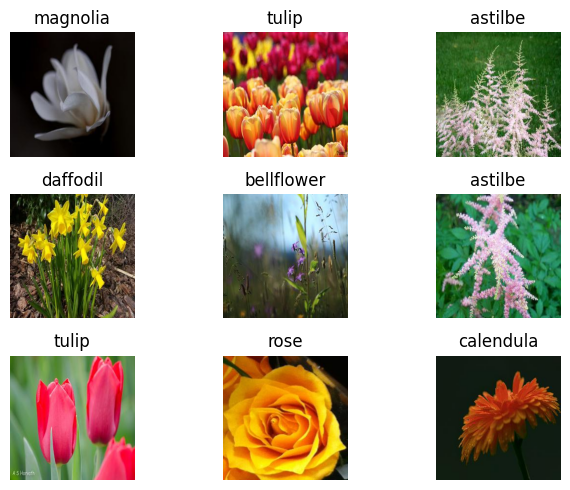

In [5]:
num_images=9
# Randomly sample num_images from the DataFrame
sampled_df = df.sample(n=num_images).reset_index(drop=True)

plt.figure(figsize=(7, 5))

for i in range(num_images):
    plt.subplot(3, 3, i + 1)

    # Read the image
    img_path = sampled_df.iloc[i]['path']
    img = plt.imread(img_path)

    plt.imshow(img)
    plt.title(sampled_df.iloc[i]['label'])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
counts=df['label'].value_counts()
counts

label
iris                1054
dandelion           1052
tulip               1048
magnolia            1048
coreopsis           1047
sunflower           1027
california_poppy    1022
black_eyed_susan    1000
rose                 999
water_lily           982
common_daisy         980
calendula            978
daffodil             970
carnation            923
bellflower           873
astilbe              737
Name: count, dtype: int64

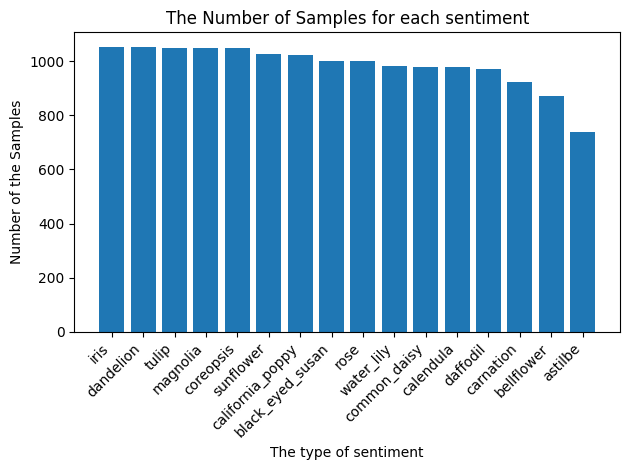

In [7]:
unique_labels=['iris', 'dandelion', 'tulip', 'magnolia', 'coreopsis', 'sunflower', 
 'california_poppy', 'black_eyed_susan', 'rose', 'water_lily', 'common_daisy', 
 'calendula', 'daffodil', 'carnation', 'bellflower', 'astilbe']
plt.bar(unique_labels, counts, width=0.8)  

plt.xlabel('The type of sentiment')
plt.ylabel('Number of the Samples')
plt.title("The Number of Samples for each sentiment")
plt.xticks(rotation=45, ha='right') 
plt.tight_layout() 
plt.show()

To test on a different batch, uncomment the batch that you want to test, and comment the previous batch

This section also samples data from each of the classes

In [ ]:
#FIRST BATCH
selected_labels=['common_daisy', 'bellflower', 'rose', 'sunflower', 'astilbe', 'black_eyed_susan', 'dandelion', 'carnation', 'water_lily', 'magnolia']
rare_samples=['iris', 'tulip', 'coreopsis', 'california_poppy', 'calendula', 'daffodil']

#SECOND BATCH
#selected_labels=['iris', 'tulip', 'coreopsis', 'california_poppy', 'calendula', 'daffodil', 'common_daisy', 'bellflower', 'rose', 'sunflower']
#rare_samples=['astilbe', 'black_eyed_susan', 'dandelion', 'carnation', 'water_lily', 'magnolia']

#THIRD BATCH
#selected_labels=['astilbe', 'black_eyed_susan', 'dandelion', 'daffodil', 'water_lily', 'magnolia', 'iris', 'tulip', 'california_poppy', 'calendula']
#rare_samples=['common_daisy', 'bellflower', 'rose', 'sunflower', 'coreopsis', 'carnation']

#FOURTH BATCH
#selected_labels=['astilbe', 'water_lily', 'iris', 'calendula', 'common_daisy', 'rose', 'carnation', 'dandelion', 'california_poppy', 'coreopsis']
#rare_samples=['black_eyed_susan', 'magnolia', 'tulip', 'daffodil', 'bellflower', 'sunflower']

#FIFTH BATCH
#selected_labels=['black_eyed_susan', 'bellflower', 'calendula', 'coreopsis', 'daffodil', 'iris', 'magnolia', 'rose', 'tulip', 'water_lily']
#rare_samples=['astilbe', 'california_poppy', 'carnation', 'common_daisy', 'dandelion','sunflower']
import pandas as pd

def select_and_sample_classes(df, selected_labels, rare_samples, num_samples=700, rare_num=20):

    # Filter the DataFrame for selected labels
    filtered_df = df[df['label'].isin(selected_labels)]
    
    sampled_df = pd.DataFrame()
    for label in selected_labels:
        label_df = filtered_df[filtered_df['label'] == label].sample(n=num_samples, replace=True)
        sampled_df = pd.concat([sampled_df, label_df], ignore_index=True)
    
    rare_df = df[df['label'].isin(rare_samples)]
    for label in rare_samples:
        label_df = rare_df[rare_df['label'] == label].sample(n=rare_num, replace=True)
        sampled_df = pd.concat([sampled_df, label_df], ignore_index=True)

    return sampled_df

def sample_common_classes(df, selected_labels, num_samples=700):

    filtered_df = df[df['label'].isin(selected_labels)]
    
    sampled_df = pd.DataFrame()
    for label in selected_labels:
        label_df = filtered_df[filtered_df['label'] == label].sample(n=num_samples, replace=True)
        sampled_df = pd.concat([sampled_df, label_df], ignore_index=True)

    return sampled_df

    

def sample_rare_classes(df, rare_samples, num_samples=700):

    sampled_df = pd.DataFrame()
    
    rare_df = df[df['label'].isin(rare_samples)]
    for label in rare_samples:
        label_df = rare_df[rare_df['label'] == label].sample(n=num_samples, replace=True)
        sampled_df = pd.concat([sampled_df, label_df], ignore_index=True)

    return sampled_df


#sampled_df = select_and_sample_classes(df, selected_labels, rare_samples, num_samples=700, rare_num=30)
#sampled_df['label'].value_counts()

common_df = sample_common_classes(df, selected_labels, num_samples=700) 
rare_df = sample_rare_classes(df, rare_samples, num_samples=180) 

common_df['label'].value_counts()
rare_df['label'].value_counts()

label
astilbe             180
california_poppy    180
carnation           180
common_daisy        180
dandelion           180
sunflower           180
Name: count, dtype: int64

Split data into training, testing and validation data, then merge the common and rare groups.

In [9]:
# Splitting data into training (70%), testing (15%), and validation (15%) sets
common_train, common_temp = train_test_split(common_df, test_size=0.3, random_state=42)
common_test, common_valid = train_test_split(common_temp, test_size=0.5, random_state=42)

rare_valid, rare_temp = train_test_split(rare_df, test_size=1/6, random_state=42)
rare_test, rare_train = train_test_split(rare_temp, test_size=0.5, random_state=42)

#train_df, temp_df = train_test_split(sampled_df, test_size=0.3, random_state=10)
#test_df, valid_df = train_test_split(temp_df, test_size=0.5, random_state=10)

train_df = pd.concat([common_train, rare_train], ignore_index=True)
test_df = pd.concat([common_test, rare_test], ignore_index=True)
valid_df = pd.concat([common_valid, rare_valid], ignore_index=True)

print("Training set shapes:", train_df.shape)
print("Testing set shapes:", test_df.shape)
print("Validation set shapes:", valid_df.shape)

Training set shapes: (4990, 2)
Testing set shapes: (1140, 2)
Validation set shapes: (1950, 2)


Initialize data generators

In [10]:
train_datagen = ImageDataGenerator(    
    rescale=1.0/255,        
    shear_range=0.2,
    rotation_range=.1,
    zoom_range=0.2,       
    horizontal_flip=True ,
)
test_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
# Training data generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path', 
    y_col='label',   
    target_size=(224, 224), 
    batch_size=32,
    class_mode='categorical', 
    color_mode='rgb',
    shuffle=True
)

# Validation data generator
valid_generator = test_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='path', 
    y_col='label',
    target_size=(224, 224), 
    batch_size=32,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False  
)

# Testing data generator
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path', 
    y_col='label',  
    target_size=(224, 224),  
    color_mode='rgb',
    batch_size=64,  
    class_mode='categorical',
    shuffle=False  
)

Found 4990 validated image filenames belonging to 16 classes.
Found 1950 validated image filenames belonging to 16 classes.
Found 1140 validated image filenames belonging to 16 classes.


In [12]:
classes=list(train_generator.class_indices)
classes

['astilbe',
 'bellflower',
 'black_eyed_susan',
 'calendula',
 'california_poppy',
 'carnation',
 'common_daisy',
 'coreopsis',
 'daffodil',
 'dandelion',
 'iris',
 'magnolia',
 'rose',
 'sunflower',
 'tulip',
 'water_lily']

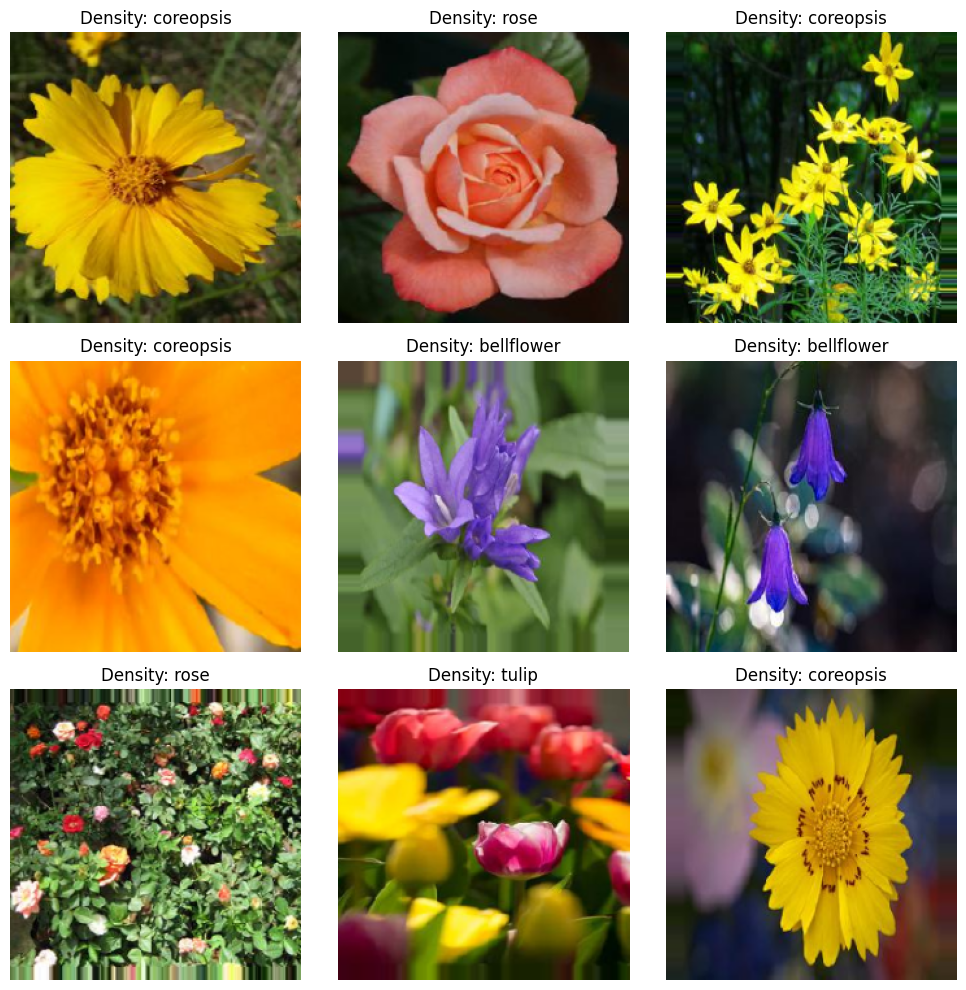

In [13]:
batch_size = 9
# Generate a batch of images and labels
images, labels = next(train_generator)
# Plot the images with their labels
plt.figure(figsize=(10, 10))
for i in range(min(len(images), 9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    label = np.argmax(labels[i])
    plt.title(f"Density: {classes[label]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Initialize model, show summary of shape

In [14]:
model=keras.models.Sequential()

model.add(Conv2D(64,(3,3),input_shape=(224,224,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.1))


model.add(Conv2D(64,(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(16,activation='softmax')) #MAYBE 10?
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    95,552,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         8,208 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,601,232 (364.69 MB)

 Trainable params: 95,600,080 (364.69 MB)

 Non-trainable params: 1,152 (4.50 KB)

Establish training process, and train for 40 epochs

In [16]:
weight_path = "cnn_weights.best.weights.h5"

checkpoint = ModelCheckpoint(weight_path, monitor='val_accuracy', verbose=1, 
                             save_best_only=True, mode='max', save_weights_only=True)

early = EarlyStopping(monitor="val_accuracy", 
                      mode="max", 
                      patience=7)

callbacks_list = [checkpoint, early]

In [17]:
epoch_num=40
history=model.fit(train_generator,epochs=epoch_num,validation_data=(valid_generator),callbacks=callbacks_list)

Epoch 1/40
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.3635 - loss: 2.1578
Epoch 1: val_accuracy improved from -inf to 0.12974, saving model to cnn_weights.best.weights.h5
156/156 ━━━━━━━━━━━━━━━━━━━━ 148s 939ms/step - accuracy: 0.3639 - loss: 2.1557 - val_accuracy: 0.1297 - val_loss: 3.5220
Epoch 2/40
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.5201 - loss: 1.4722
Epoch 2: val_accuracy improved from 0.12974 to 0.16667, saving model to cnn_weights.best.weights.h5
156/156 ━━━━━━━━━━━━━━━━━━━━ 130s 836ms/step - accuracy: 0.5201 - loss: 1.4719 - val_accuracy: 0.1667 - val_loss: 3.4803
Epoch 3/40
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 877ms/step - accuracy: 0.5603 - loss: 1.3040
Epoch 3: val_accuracy improved from 0.16667 to 0.30103, saving model to cnn_weights.best.weights.h5
156/156 ━━━━━━━━━━━━━━━━━━━━ 150s 960ms/step - accuracy: 0.5604 - loss: 1.3037 - val_accuracy: 0.3010 - val_loss: 2.9175
Epoch 4/40
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 809ms/step - accuracy: 0.6302 - l

In [18]:
# load the best weights
model.load_weights(weight_path)

In [19]:
# Evaluate the model on the test data
evaluation_result = model.evaluate(valid_generator)

# The result
print("Test Loss:", evaluation_result[0])
print("Test Accuracy:", evaluation_result[1])

61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.7150 - loss: 1.2241
Test Loss: 2.5921385288238525
Test Accuracy: 0.5046153664588928


In [20]:
#  predictions on test data
y_pred = model.predict(valid_generator)

61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step


[3, 10, 2, 11, 12, 12, 8, 11, 12, 7, 3, 8, 8, 15, 11, 11, 1, 2, 11, 15, 2, 11, 3, 11, 1, 12, 3, 15, 14, 1, 1, 12, 8, 7, 7, 14, 3, 10, 7, 3, 1, 1, 3, 14, 14, 8, 8, 12, 8, 14, 1, 2, 8, 12, 8, 15, 11, 3, 10, 14, 3, 12, 14, 14, 7, 8, 14, 14, 7, 7, 8, 7, 14, 3, 1, 15, 2, 1, 10, 11, 12, 15, 7, 7, 1, 14, 8, 2, 12, 2, 8, 11, 1, 15, 11, 2, 3, 10, 2, 2, 7, 7, 10, 2, 11, 15, 3, 10, 11, 10, 12, 7, 14, 8, 3, 3, 14, 8, 14, 11, 11, 14, 7, 3, 7, 11, 7, 10, 12, 8, 15, 12, 12, 10, 1, 10, 8, 2, 10, 7, 2, 11, 14, 10, 8, 10, 2, 3, 2, 15, 3, 11, 14, 12, 10, 15, 2, 2, 12, 3, 3, 2, 14, 8, 8, 14, 11, 11, 3, 14, 7, 3, 12, 14, 2, 1, 12, 11, 8, 14, 14, 14, 12, 7, 15, 10, 10, 10, 15, 14, 14, 1, 15, 15, 11, 2, 8, 12, 14, 12, 14, 1, 10, 3, 14, 8, 12, 3, 15, 14, 8, 1, 3, 15, 12, 15, 11, 2, 8, 7, 1, 15, 10, 7, 7, 10, 11, 12, 2, 14, 8, 3, 11, 8, 7, 10, 10, 1, 10, 8, 8, 14, 2, 2, 11, 1, 8, 2, 2, 10, 3, 12, 7, 2, 1, 2, 15, 3, 12, 7, 2, 12, 2, 15, 8, 14, 15, 14, 12, 10, 8, 3, 8, 14, 12, 2, 8, 2, 1, 7, 15, 15, 11, 10, 8, 7

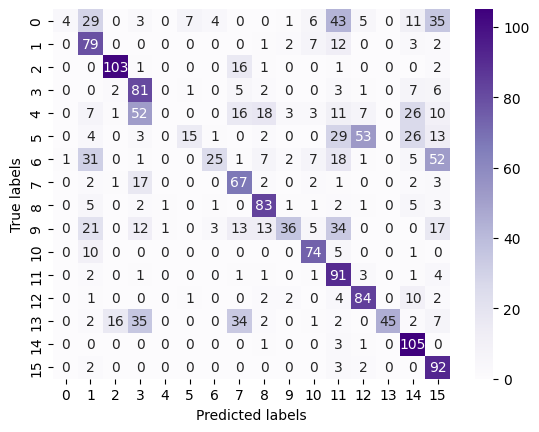

In [21]:
y_pred_classes = np.argmax(y_pred, axis=1)
#  y_test is one-hot encoded
y_test_classes = valid_generator.classes

print(test_generator.classes)


confusion_Matrix = confusion_matrix(y_test_classes, y_pred_classes)

# Plotting the confusion matrix as a heatmap
sns.heatmap(confusion_Matrix, annot=True, cmap='Purples', fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

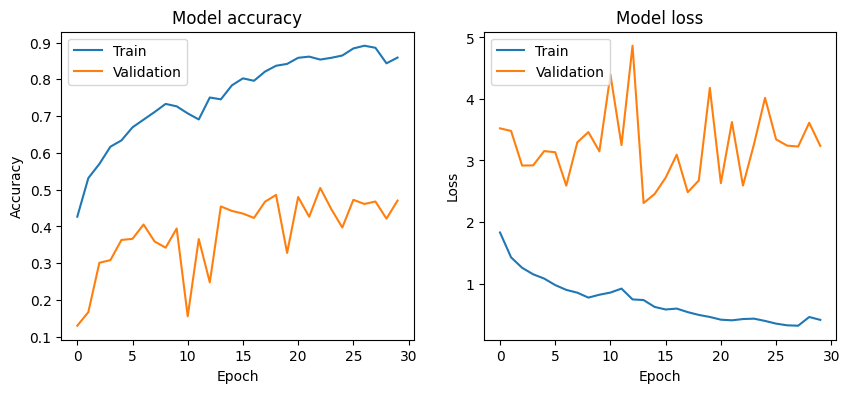

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
# Plot the training and validation accuracy
ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_title('Model accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Validation'], loc='upper left')

# Plot the training and validation loss
ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_title('Model loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Validation'], loc='upper left')

# Display the plots
plt.show()

In [23]:
print(classification_report(y_test_classes, y_pred_classes))

              precision    recall  f1-score   support

           0       0.80      0.03      0.05       148
           1       0.41      0.75      0.52       106
           2       0.84      0.83      0.83       124
           3       0.39      0.75      0.51       108
           4       0.00      0.00      0.00       154
           5       0.62      0.10      0.18       146
           6       0.74      0.17      0.27       151
           7       0.44      0.69      0.54        97
           8       0.61      0.79      0.69       105
           9       0.77      0.23      0.36       155
          10       0.69      0.82      0.75        90
          11       0.35      0.87      0.50       105
          12       0.53      0.79      0.64       106
          13       1.00      0.31      0.47       146
          14       0.51      0.95      0.67       110
          15       0.37      0.93      0.53        99

    accuracy                           0.50      1950
   macro avg       0.57   

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


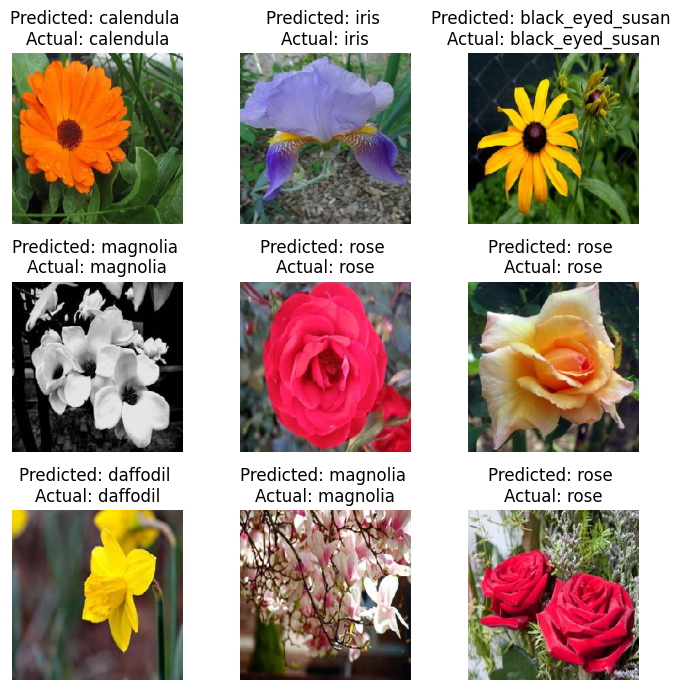

In [24]:
x_test,y_test=next(test_generator)
# make a figure that images will be shown in
fig, axs = plt.subplots(3, 3, figsize=(7, 7))
axs = axs.flatten()

for i in range(9):
    #predict image
    predicted = model.predict(np.array([x_test[i]]))
    # take larger value which is predicted class
    predictedClass = np.argmax(predicted)
    actual = np.argmax(y_test[i])
    # plot actual class and predicted with the image
    axs[i].imshow(x_test[i], cmap='gray')
    axs[i].set_title(f'Predicted: {classes[predictedClass]} \nActual: {classes[actual]}')
    axs[i].axis('off')

plt.tight_layout()
plt.show()